In [1]:
import os , cv2 , shutil , random , pathlib
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
imgs_path = pathlib.Path('images')
masks_path = pathlib.Path('mask')

In [3]:
def preprocess_images(input_dir : pathlib.Path , output_dir : pathlib.Path):
    images = os.listdir(input_dir)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir , exist_ok=True)
    for image in images:
        img = Image.open(input_dir/image).resize((640,640)).convert('RGB').save(output_dir / image)
    print("done")


In [4]:
preprocess_images(imgs_path , imgs_path)
preprocess_images(masks_path , masks_path)

done
done


## that is the normal bounding box creation based on cv2 bounding box

In [5]:
def segmentImg(img , mask):
    image = cv2.imread(img)
    mask = cv2.imread(mask)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)    
    width = image.shape[1]
    height = image.shape[0]
    print(width , height)
    x /= width
    y /= height
    w /= width
    h /= height
    
    return (x) , (y) , (w) , (h) 

640 640
x :  0.11875 
y :  0.171875 
w :  0.665625 
h :  0.60625


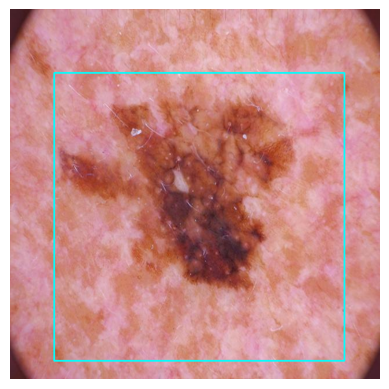

In [6]:
x, y, w, h = segmentImg('./images/ISIC_0024310.jpg','./mask/ISIC_0024310_segmentation.png')
print('x : ', x  , '\ny : ' , y  , '\nw : ', w  , '\nh : ' , h )

x *= 640
y *= 640
w *= 640
h *= 640

w += x
h+= y

img = cv2.imread('./images/ISIC_0024310.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 255), 2)

plt.imshow(img)
plt.axis('off')
plt.show()

## that we used to create the bounding box based on the yolo model label file

In [7]:
def segment_img_yolo(img, mask):
    image = cv2.imread(img)
    mask = cv2.imread(mask)

    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    # Find the contours of the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Get the largest contour
    largest_contour = max(contours, key=cv2.contourArea)
    # Get the minimum area rectangle that is rotated to align with the principal axis of the object
    rect = cv2.minAreaRect(largest_contour)
    print(rect)
    # Get the coordinates of the rotated rectangle
    (x, y), (w, h), angle = rect

    width = image.shape[1]
    height = image.shape[0]
    print(width , height)
    x /= width
    y /= height
    w /= width
    h /= height

    return x, y, w, h


In [8]:
x, y, w, h = segment_img_yolo('./images/ISIC_0024310.jpg','./mask/ISIC_0024310_segmentation.png')
print('x : ', x  , '\ny : ' , y  , '\nw : ', w  , '\nh : ' , h )

((276.0614929199219, 287.85589599609375), (410.7248840332031, 373.43975830078125), 16.76255226135254)
640 640
x :  0.43134608268737795 
y :  0.44977483749389646 
w :  0.6417576313018799 
h :  0.5834996223449707


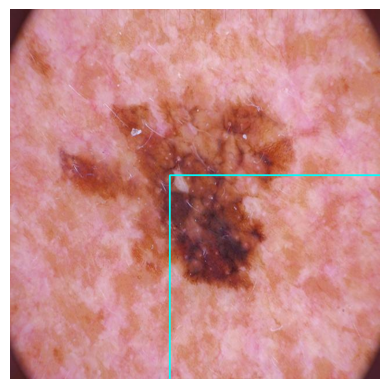

In [9]:
image = cv2.imread('./images/ISIC_0024310.jpg')
x *= 640
y *= 640
w *= 640
h *= 640
w += x
h+= y
img = cv2.imread('./images/ISIC_0024310.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(img, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 255), 2)
plt.imshow(img)
plt.axis('off')
plt.show()


In [10]:
images_path = 'images'
masks_path = 'mask'
label_path = 'labels'

if not os.path.exists(label_path):
    os.makedirs(label_path)

In [11]:
truth = pd.read_csv('GroundTruth.csv')
file_name = truth.iloc[:,0]
MEL = truth.iloc[:,1]
NV = truth.iloc[:,2]
BCC = truth.iloc[:,3]
AKIEC = truth.iloc[:,4]
BKL = truth.iloc[:,5]
DF = truth.iloc[:,6]
VASC = truth.iloc[:,7]

In [12]:
name_len = len(file_name[0])

In [13]:
for i , j in enumerate(file_name):
    for filename in os.listdir(images_path):
        if j == filename[:name_len] and MEL[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(4) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
        if j == filename[:name_len] and NV[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(5) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and BCC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(1) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        elif j == filename[:name_len] and AKIEC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(0) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and BKL[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(2) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and DF[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(3) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                
        if j == filename[:name_len] and VASC[i] == 1:
            xmin, ymin, xmax, ymax = segment_img_yolo(images_path + '/' + filename , masks_path+'/'+j+'_segmentation.png' )
            with open('labels/' +filename[:name_len] +'.txt' , "a+") as f:
                f.write(str(6) + ' ' +str(xmin)+' ' +str(ymin)+' ' +str(xmax)+' '+str(ymax))
                

((367.5094299316406, 302.37890625), (349.1114501953125, 586.94775390625), 0.8680514693260193)
640 640
((356.4034423828125, 322.92852783203125), (538.3344116210938, 414.6428527832031), 79.545166015625)
640 640
((331.3099365234375, 358.89691162109375), (672.8701171875, 336.8175048828125), 60.09406280517578)
640 640
((266.55731201171875, 396.63763427734375), (478.1966857910156, 386.14434814453125), 87.82868957519531)
640 640
((276.0614929199219, 287.85589599609375), (410.7248840332031, 373.43975830078125), 16.76255226135254)
640 640
((314.8091735839844, 375.45196533203125), (330.71636962890625, 520.44482421875), 46.517417907714844)
640 640
((323.91302490234375, 321.5640869140625), (550.2301025390625, 418.4742126464844), 87.11485290527344)
640 640
((302.60235595703125, 317.76715087890625), (312.11614990234375, 196.74000549316406), 2.361374616622925)
640 640
((318.33056640625, 324.2716369628906), (260.7353515625, 243.200439453125), 0.993468701839447)
640 640
((298.7767333984375, 293.9547424

In [14]:
class_names = sorted(list(truth.columns)[1:])
text_yolo_data_file = f"""
train : ../train/images
test : ../test/images

nc : {len(class_names)}
names = : {class_names}

powered by:
    workplace: local
    version: 1
    license: no license
"""

In [15]:
with open('data.yaml' , 'a+' , encoding="utf-8") as f:
    f.write(text_yolo_data_file)

In [16]:
# === CONFIG ===
images_dir = './images'
labels_dir = './labels'
output_base = './dataset'
split_ratio = 0.8  # 80% train, 20% test
seed = 42

In [19]:
# === Ensure reproducibility ===
random.seed(seed)

In [20]:
# === Get file list ===
image_files = [f for f in os.listdir(images_dir) if os.path.isfile(os.path.join(images_dir, f))]
random.shuffle(image_files)

In [22]:
# === Split ===
split_index = int(len(image_files) * split_ratio)
train_files = image_files[:split_index]
test_files = image_files[split_index:]

In [23]:
# === Directory structure ===
for split in ['train', 'test']:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'labels'), exist_ok=True)


In [24]:
# === Move files ===
def copy_files(file_list, split):
    for filename in file_list:
        # Copy image
        src_img = os.path.join(images_dir, filename)
        dst_img = os.path.join(output_base, split, 'images', filename)
        shutil.copy2(src_img, dst_img)

        # Copy label (change extension if needed)
        name, _ = os.path.splitext(filename)
        for ext in ['.txt', '.xml', '.json']:  # Try common label extensions
            label_file = name + ext
            src_label = os.path.join(labels_dir, label_file)
            if os.path.exists(src_label):
                dst_label = os.path.join(output_base, split, 'labels', label_file)
                shutil.copy2(src_label, dst_label)
                break
        else:
            print(f"⚠️ Label not found for: {filename}")

In [25]:
copy_files(train_files, 'train')
copy_files(test_files, 'test')

print(f"✅ Split complete. {len(train_files)} training and {len(test_files)} testing samples.")

✅ Split complete. 16 training and 4 testing samples.
